In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
from scipy import optimize

# Use Cholesky decomposition to simulate the return vector given means, vols and correlation matrix.

In [16]:
rng = np.random.default_rng(seed=42)

# Configuration
means = np.array([0.05, 0.09, 0.07, 0.06])
vols = np.array([0.04, 0.15, 0.05, 0.1])
vol_mat = np.diag(vols)
correlation_mat = np.array(
    [
        [1.0, 0.1, 0.4, -0.1],
        [0.1, 1.0, 0.2, -0.1],
        [0.4, 0.2, 1.0, -0.2],
        [-0.1, -0.1, -0.2, 1.0],
    ]
)
cov_matrix = vol_mat @ correlation_mat @ vol_mat
num_samples = 2500

# # 1. Compute Lower Cholesky factor
L = np.linalg.cholesky(cov_matrix)

# # 2. Generate independent standard normal random variables (3 variables x 5000 samples)
Z = rng.standard_normal((len(means), num_samples))

# # 3. Transform to correlated variables and add the means
X = means + (L @ Z).T
X = X.T  # Transpose to get a 5000x3 shape
cov_matrix

array([[ 0.0016,  0.0006,  0.0008, -0.0004],
       [ 0.0006,  0.0225,  0.0015, -0.0015],
       [ 0.0008,  0.0015,  0.0025, -0.001 ],
       [-0.0004, -0.0015, -0.001 ,  0.01  ]])

# Denoise the covariance matrix using Random Matrix Theory

In [53]:
standardized_cov_mat = np.cov(((X.T - means) / vols).T)
for i in range(len(standardized_cov_mat)):
    standardized_cov_mat[i, i] = 1.0
standardized_cov_mat

array([[ 1.        ,  0.10254387,  0.40320016, -0.10773046],
       [ 0.10254387,  1.        ,  0.20166364, -0.10406186],
       [ 0.40320016,  0.20166364,  1.        , -0.2061374 ],
       [-0.10773046, -0.10406186, -0.2061374 ,  1.        ]])

In [54]:
eigenvalues, eigenvectors = np.linalg.eig(standardized_cov_mat)

print("Eigenvalues:", eigenvalues)
print("Eigenvectors (columns):\n", eigenvectors)

Eigenvalues: [1.59975639 0.57333225 0.93119606 0.89571531]
Eigenvectors (columns):
 [[-0.55852738 -0.62476592 -0.54383471  0.04425515]
 [-0.37483477 -0.16271459  0.62594409  0.66424156]
 [-0.63314772  0.74606783 -0.20530039  0.01893424]
 [ 0.38297522  0.16301625 -0.51989379  0.74596657]]


In [42]:
lambda_max = 1.0**2 * (
    1 + len(means) / num_samples + 2 * np.sqrt(len(means) / num_samples)
)
lambda_max

1.0179685438199984

In [48]:
new_eigenval = eigenvalues[eigenvalues < lambda_max].mean()
print(eigenvalues)
new_eigenvalues = eigenvalues.copy()
new_eigenvalues = np.where(new_eigenvalues < lambda_max, new_eigenval, eigenvalues)
print("Old eigenvalues:", eigenvalues)
print("New eigenvalues:", new_eigenvalues)

[1.60670845 0.58105478 0.93748221 0.89967442]
Old eigenvalues: [1.60670845 0.58105478 0.93748221 0.89967442]
New eigenvalues: [1.60670845 0.80607047 0.80607047 0.80607047]


In [60]:
denoised_cov_mat = (
    np.diag(vols)
    @ eigenvectors
    @ np.diag(new_eigenvalues)
    @ eigenvectors.T
    @ np.diag(vols)
)
denoised_cov_mat

array([[ 0.00168933,  0.00100571,  0.00056626, -0.00068503],
       [ 0.00100571,  0.02066762,  0.00142509, -0.001724  ],
       [ 0.00056626,  0.00142509,  0.00281757, -0.00097069],
       [-0.00068503, -0.001724  , -0.00097069,  0.009235  ]])

In [114]:
w = cp.Variable(len(means))
gamma = cp.Parameter(nonneg=True)
ret = means.T @ w
risk = cp.quad_form(w, denoised_cov_mat)
prob = cp.Problem(cp.Minimize(risk - gamma * ret), [cp.sum(w) == 1])

In [115]:
_SAMPLES = 200
risk_data_denoised = np.zeros(_SAMPLES)
ret_data_denoised = np.zeros(_SAMPLES)
gamma_vals = np.logspace(-6, 0.1, num=_SAMPLES)
for i in range(_SAMPLES):
    gamma.value = gamma_vals[i]
    prob.solve()
    risk_data_denoised[i] = cp.sqrt(risk).value
    ret_data_denoised[i] = ret.value

In [116]:
w = cp.Variable(len(means))
gamma = cp.Parameter(nonneg=True)
ret = means.T @ w
risk = cp.quad_form(w, cov_matrix)
prob2 = cp.Problem(cp.Minimize(risk - gamma * ret), [cp.sum(w) == 1])

In [117]:
_SAMPLES = 200
risk_data_wo_denoised = np.zeros(_SAMPLES)
ret_data_wo_denoised = np.zeros(_SAMPLES)
gamma_vals = np.logspace(-6, 0.1, num=_SAMPLES)
for i in range(_SAMPLES):
    gamma.value = gamma_vals[i]
    prob2.solve()
    risk_data_wo_denoised[i] = cp.sqrt(risk).value
    ret_data_wo_denoised[i] = ret.value

In [ ]:
w.

array([-5.15956036,  0.79171432,  4.7694665 ,  0.59837955])

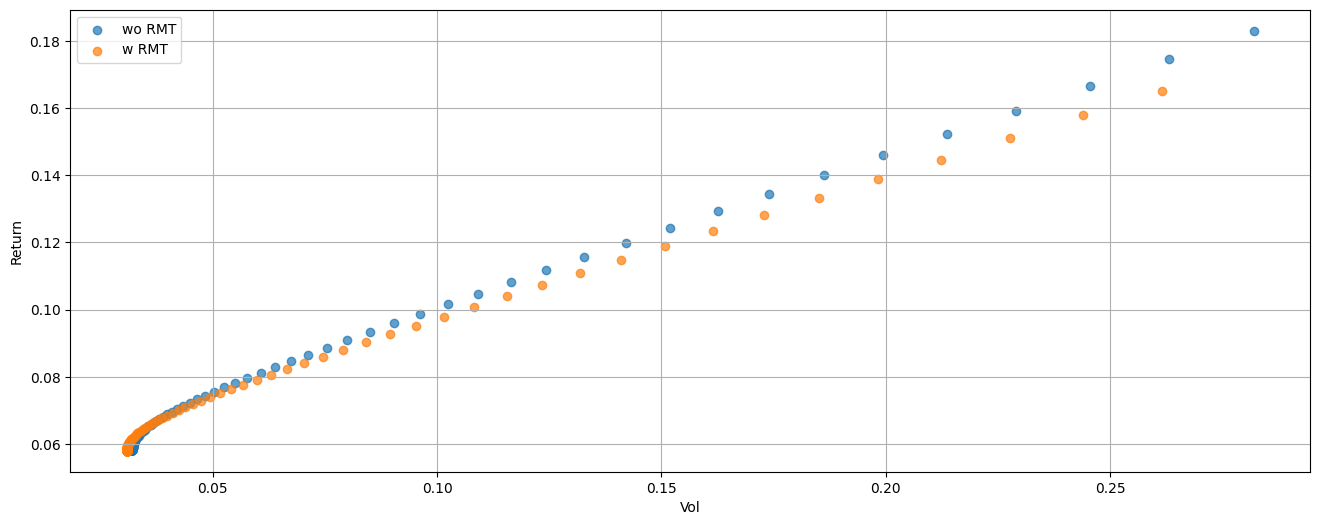

In [120]:
plt.figure(figsize=(16, 6))
plt.scatter(risk_data_wo_denoised, ret_data_wo_denoised, label="wo RMT", alpha=0.7)
plt.scatter(risk_data_denoised, ret_data_denoised, label="w RMT", alpha=0.7)
plt.grid()
plt.xlabel("Vol")
plt.ylabel("Return")
plt.legend()
plt.show()

# Integrate Boostrapping with RMT denoising to make efficient frontier robust

In [17]:
def find_optimal_portfolio(gamma_range: list[float, float], target: float, is_mu: bool):
    def bisection_method(tmp_gamma):
        nonlocal target, is_mu
        gamma.value = tmp_gamma
        prob.solve()
        if is_mu:
            return ret.value - target
        else:
            return cp.sqrt(risk).value - target

    out = optimize.bisect(bisection_method, gamma_range[0], gamma_range[1])
    gamma.value = out
    prob.solve()
    print("optimal risk:", cp.sqrt(risk).value, "optimal return:", ret.value)
    return out, float(cp.sqrt(risk).value), ret.value

In [18]:
n_boostrapping = 1000  # 1000 will give 1000 efficient frontiers
target_return = 0.1
is_mu = True
weights = {"w" + str(i + 1): [] for i in range(len(means))}
for i in range(n_boostrapping):
    Z = rng.standard_normal((len(means), num_samples))
    X = means + (L @ Z).T
    X = X.T
    standardized_cov_mat = np.cov(((X.T - means) / vols).T)
    # Ensure that the diagonal elements are 1.0
    for j in range(len(standardized_cov_mat)):
        standardized_cov_mat[j, j] = 1.0
    eigenvalues, eigenvectors = np.linalg.eig(standardized_cov_mat)
    lambda_max = 1.0**2 * (
        1 + len(means) / num_samples + 2 * np.sqrt(len(means) / num_samples)
    )
    new_eigenval = eigenvalues[eigenvalues < lambda_max].mean()
    # print(eigenvalues)
    new_eigenvalues = eigenvalues.copy()
    new_eigenvalues = np.where(new_eigenvalues < lambda_max, new_eigenval, eigenvalues)
    # print("Old eigenvalues:", eigenvalues)
    # print("New eigenvalues:", new_eigenvalues)
    denoised_cov_mat = (
        np.diag(vols)
        @ eigenvectors
        @ np.diag(new_eigenvalues)
        @ eigenvectors.T
        @ np.diag(vols)
    )
    w = cp.Variable(len(means))
    gamma = cp.Parameter(nonneg=True)
    ret = means.T @ w
    risk = cp.quad_form(w, denoised_cov_mat)
    prob = cp.Problem(cp.Minimize(risk - gamma * ret), [cp.sum(w) == 1])
    tmp_gamma, port_vol, port_mean = find_optimal_portfolio(
        gamma_range=[1e-6, 10], target=target_return, is_mu=is_mu
    )
    print(
        "Iteration:",
        i,
        "Optimal Portfolio Mean:",
        port_mean,
        "Optimal Portfolio Vol:",
        port_vol,
    )
    prob = cp.Problem(cp.Minimize(risk - tmp_gamma * ret), [cp.sum(w) == 1, w >= 0])
    prob.solve()
    print(w.value)
    for j in range(len(means)):
        weights["w" + str(j + 1)].append(w.value[j])
    print("-------------------------------------------------")
    print()

optimal risk: 0.1049248386748819 optimal return: 0.10000000000004544
Iteration: 0 Optimal Portfolio Mean: 0.10000000000004544 Optimal Portfolio Vol: 0.1049248386748819
[-2.38868129e-22  3.14365516e-01  6.10844579e-01  7.47899058e-02]
-------------------------------------------------

optimal risk: 0.10662475168113797 optimal return: 0.0999999999999178
Iteration: 1 Optimal Portfolio Mean: 0.0999999999999178 Optimal Portfolio Vol: 0.10662475168113797
[3.23022807e-23 3.13986896e-01 6.23853617e-01 6.21594865e-02]
-------------------------------------------------

optimal risk: 0.1053272861741444 optimal return: 0.09999999999999969
Iteration: 2 Optimal Portfolio Mean: 0.09999999999999969 Optimal Portfolio Vol: 0.1053272861741444
[5.56865434e-23 3.05284953e-01 6.11289731e-01 8.34253160e-02]
-------------------------------------------------

optimal risk: 0.10579250232654644 optimal return: 0.10000000000000062
Iteration: 3 Optimal Portfolio Mean: 0.10000000000000062 Optimal Portfolio Vol: 0.1

In [19]:
weights = pd.DataFrame(weights)
weights

,w1,w2,w3,w4
0,-2.388681e-22,0.314366,0.610845,0.074790
1,3.230228e-23,0.313987,0.623854,0.062159
2,5.568654e-23,0.305285,0.611290,0.083425
3,-1.232901e-22,0.305856,0.609562,0.084582
4,-1.999146e-23,0.313846,0.622154,0.064000
...,...,...,...,...
995,-1.055910e-22,0.298306,0.604178,0.097516
996,-3.908015e-23,0.298374,0.606243,0.095384
997,4.714453e-23,0.306103,0.630534,0.063363
998,-7.855133e-23,0.304364,0.610775,0.084861


# Optimal weights distributions

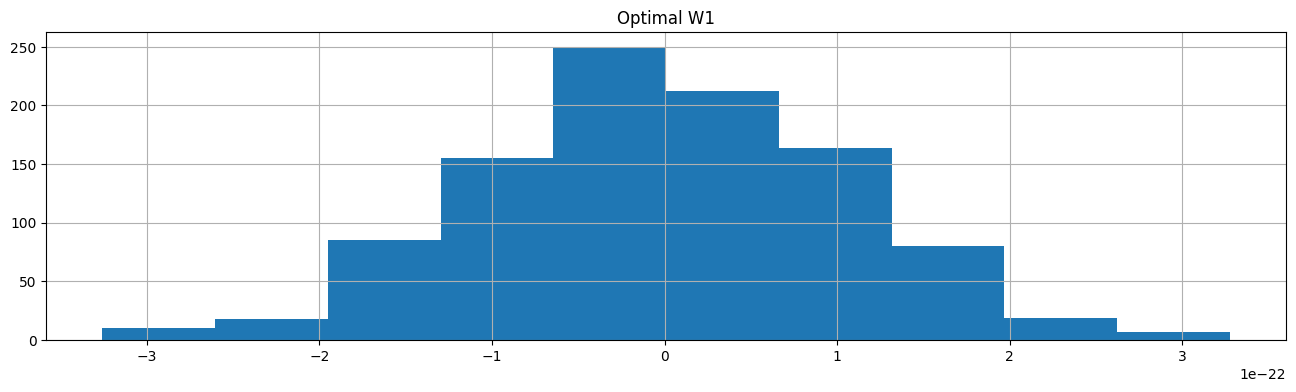

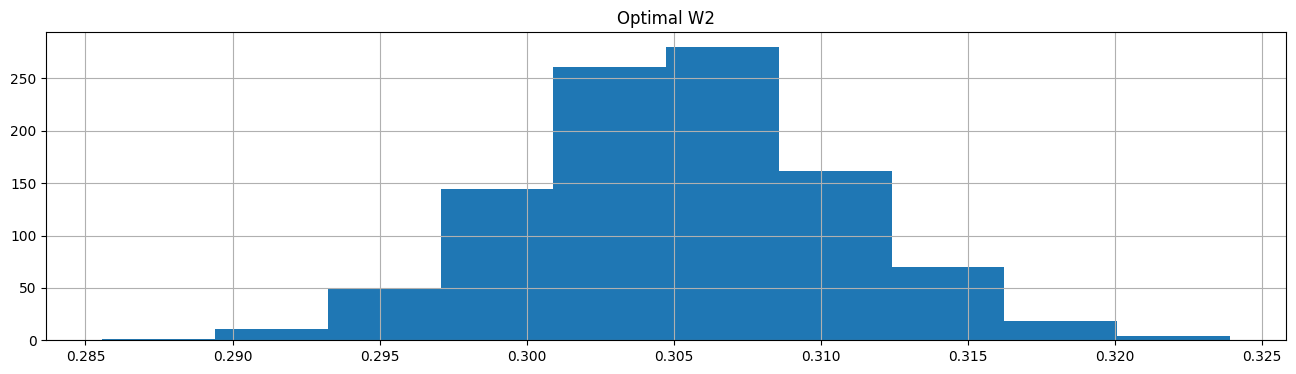

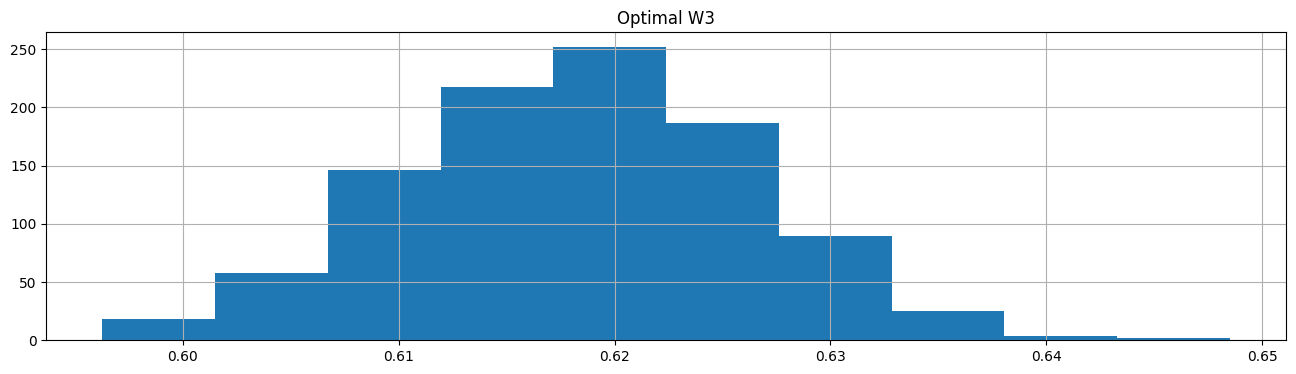

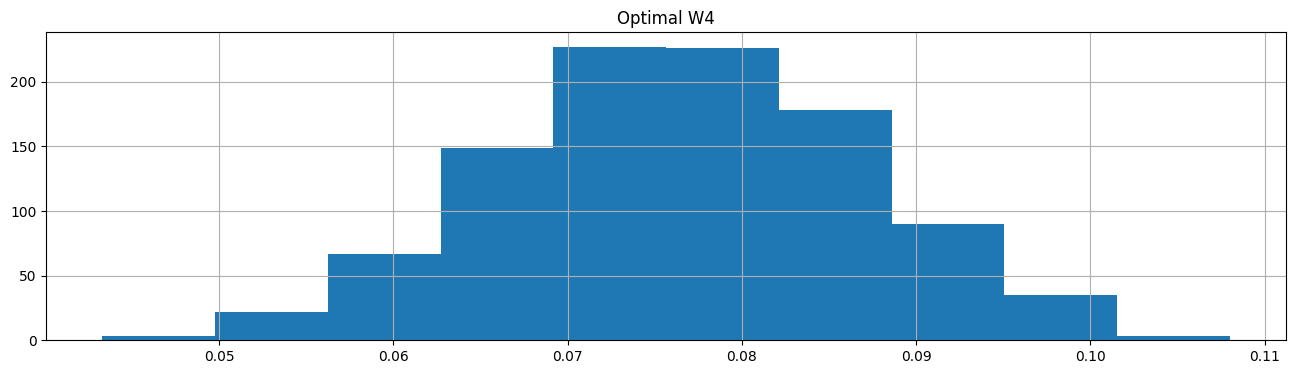

In [20]:
for i in range(len(means)):
    plt.figure(figsize=(16, 4))
    plt.hist(weights["w" + str(i + 1)])
    plt.grid()
    plt.title("Optimal W" + str(i + 1))
    plt.show()